# Análise Exploratória de Dados (EDA)
    Este notebook realiza a exploração inicial dos dados de candidatos, vagas e perspectivas.

In [9]:
#pip install matplotlib
!pip install seaborn
!pip install wordcloud

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached wordcloud-1.9.4-cp312-cp312-win_amd64.whl.metadata (3.5 kB)
Using cached wordcloud-1.9.4-cp312-cp312-win_amd64.whl (301 kB)



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Configurações de visualização
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [3]:
# Carregamento dos dados
with open('../data/applicants.json', encoding='utf-8') as f:
    applicants = json.load(f)

with open('../data/vagas.json', encoding='utf-8') as f:
    jobs = json.load(f)

with open('../data/prospects.json', encoding='utf-8') as f:
    prospects = json.load(f)



In [4]:
# Normalização
applicant_df = pd.DataFrame.from_dict(applicants, orient='index')
job_df = pd.DataFrame.from_dict(jobs, orient='index')


In [5]:
# Exibição inicial
display(applicant_df.head())
display(job_df.head())

,infos_basicas,informacoes_pessoais,informacoes_profissionais,formacao_e_idiomas,cargo_atual,cv_pt,cv_en
31000,"{'telefone_recado': '', 'telefone': '(11) 9704...",{'data_aceite': 'Cadastro anterior ao registro...,"{'titulo_profissional': '', 'area_atuacao': ''...","{'nivel_academico': '', 'nivel_ingles': '', 'n...",{},assistente administrativo\n\n\nsantosbatista\n...,
31001,"{'telefone_recado': '', 'telefone': '(11) 9372...",{'data_aceite': 'Cadastro anterior ao registro...,{'titulo_profissional': 'Analista Administrati...,{'nivel_academico': 'Ensino Superior Incomplet...,{},formação acadêmica\nensino médio (2º grau) em ...,
31002,"{'telefone_recado': '', 'telefone': '(11) 9239...",{'data_aceite': 'Cadastro anterior ao registro...,{'titulo_profissional': 'Administrativo | Fina...,{'nivel_academico': 'Ensino Superior Completo'...,{},objetivo: área administrativa | financeira\n\n...,
31003,"{'telefone_recado': '', 'telefone': '(11) 9810...",{'data_aceite': 'Cadastro anterior ao registro...,"{'titulo_profissional': 'Área administrativa',...",{'nivel_academico': 'Ensino Superior Incomplet...,{},formação\nensino médio completo\ninformática i...,
31004,"{'telefone_recado': '', 'telefone': '(11) 9251...",{'data_aceite': 'Cadastro anterior ao registro...,"{'titulo_profissional': '', 'area_atuacao': ''...","{'nivel_academico': '', 'nivel_ingles': '', 'n...",{},última atualização em 09/11/2021\n­ sp\n\nensi...,


,informacoes_basicas,perfil_vaga,beneficios
5185,"{'data_requicisao': '04-05-2021', 'limite_espe...","{'pais': 'Brasil', 'estado': 'São Paulo', 'cid...","{'valor_venda': '-', 'valor_compra_1': 'R$', '..."
5184,"{'data_requicisao': '04-05-2021', 'limite_espe...","{'pais': 'Brasil', 'estado': 'São Paulo', 'cid...","{'valor_venda': '-', 'valor_compra_1': 'R$', '..."
5183,"{'data_requicisao': '04-05-2021', 'limite_espe...","{'pais': 'Brasil', 'estado': 'São Paulo', 'cid...","{'valor_venda': '-', 'valor_compra_1': 'R$', '..."
5182,"{'data_requicisao': '04-05-2021', 'limite_espe...","{'pais': 'Brasil', 'estado': 'São Paulo', 'cid...","{'valor_venda': '- p/ mês (168h)', 'valor_comp..."
5181,"{'data_requicisao': '04-05-2021', 'limite_espe...","{'pais': 'Brasil', 'estado': 'São Paulo', 'cid...","{'valor_venda': '-', 'valor_compra_1': 'R$', '..."


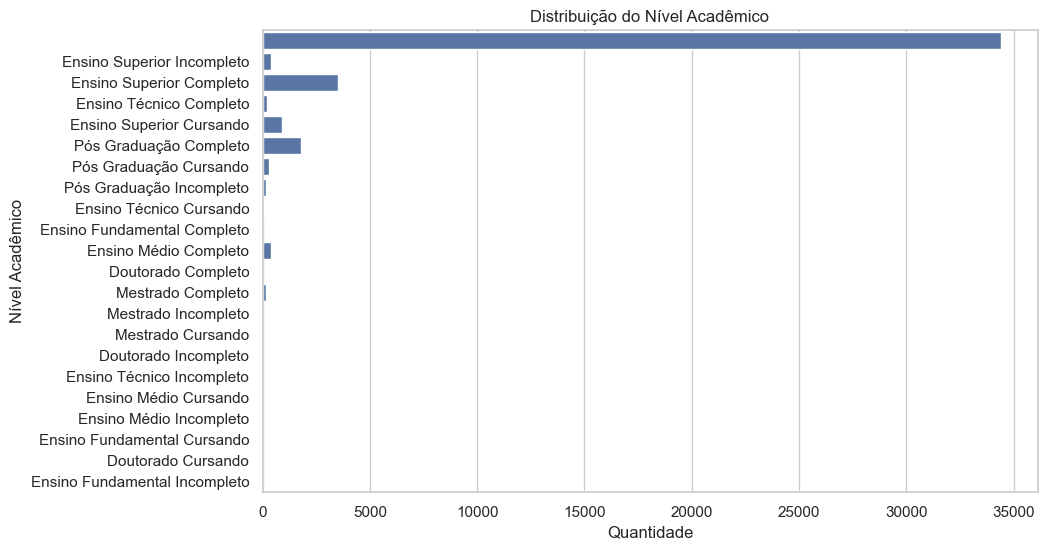

In [6]:
# Distribuição de nível acadêmico
nivel_acad = applicant_df['formacao_e_idiomas'].apply(lambda x: x.get('nivel_academico', 'Desconhecido'))
sns.countplot(y=nivel_acad)
plt.title('Distribuição do Nível Acadêmico')
plt.xlabel('Quantidade')
plt.ylabel('Nível Acadêmico')
plt.show()

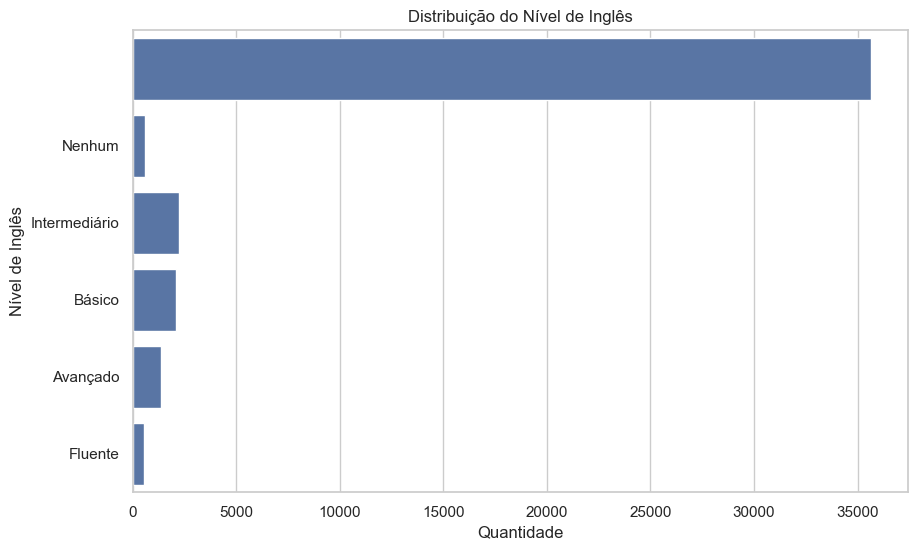

In [ ]:
# Distribuição dos níveis de idioma - ingles
nivel_ingles = applicant_df['formacao_e_idiomas'].apply(lambda x: x.get('nivel_ingles', 'Desconhecido'))
sns.countplot(y=nivel_ingles)
plt.title('Distribuição do Nível de Inglês')
plt.xlabel('Quantidade')
plt.ylabel('Nível de Inglês')
plt.show()


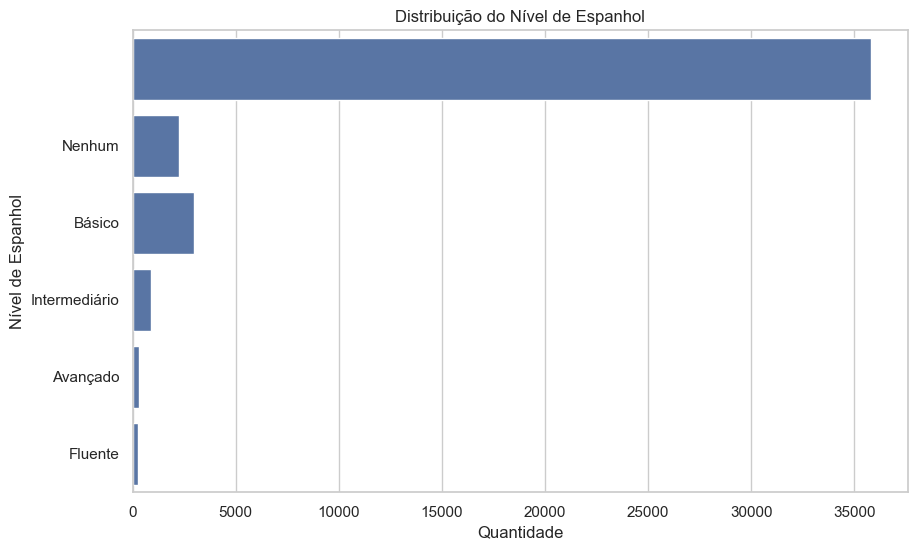

In [8]:
# Distribuição dos níveis de idioma - espanhol
nivel_espanhol = applicant_df['formacao_e_idiomas'].apply(lambda x: x.get('nivel_espanhol', 'Desconhecido'))
sns.countplot(y=nivel_espanhol)
plt.title('Distribuição do Nível de Espanhol')
plt.xlabel('Quantidade')
plt.ylabel('Nível de Espanhol')
plt.show()



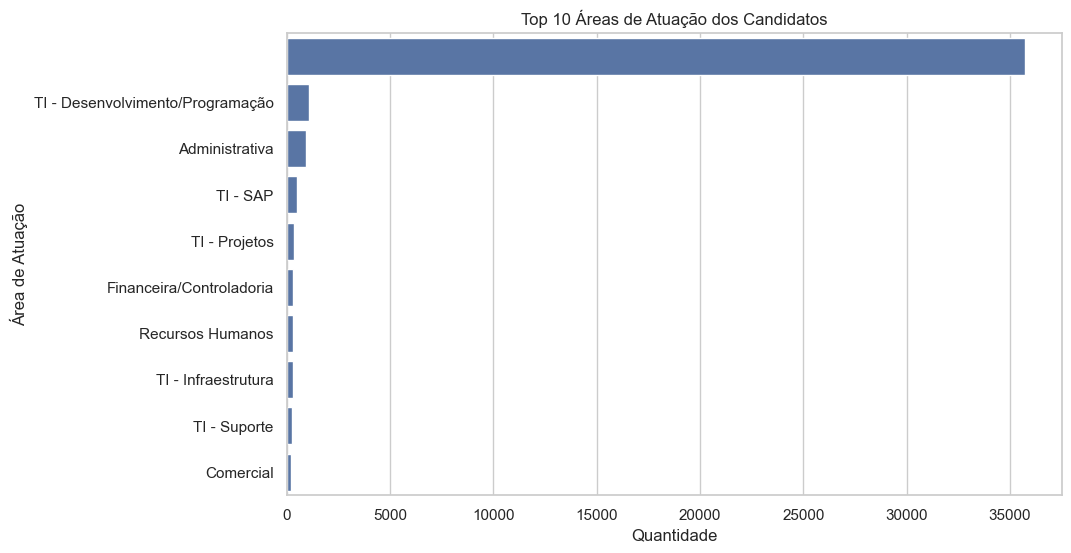

In [9]:
# Áreas de atuação
area_atuacao = applicant_df['informacoes_profissionais'].apply(lambda x: x.get('area_atuacao', 'Desconhecido'))
sns.countplot(y=area_atuacao, order=area_atuacao.value_counts().index[:10])
plt.title('Top 10 Áreas de Atuação dos Candidatos')
plt.xlabel('Quantidade')
plt.ylabel('Área de Atuação')
plt.show()

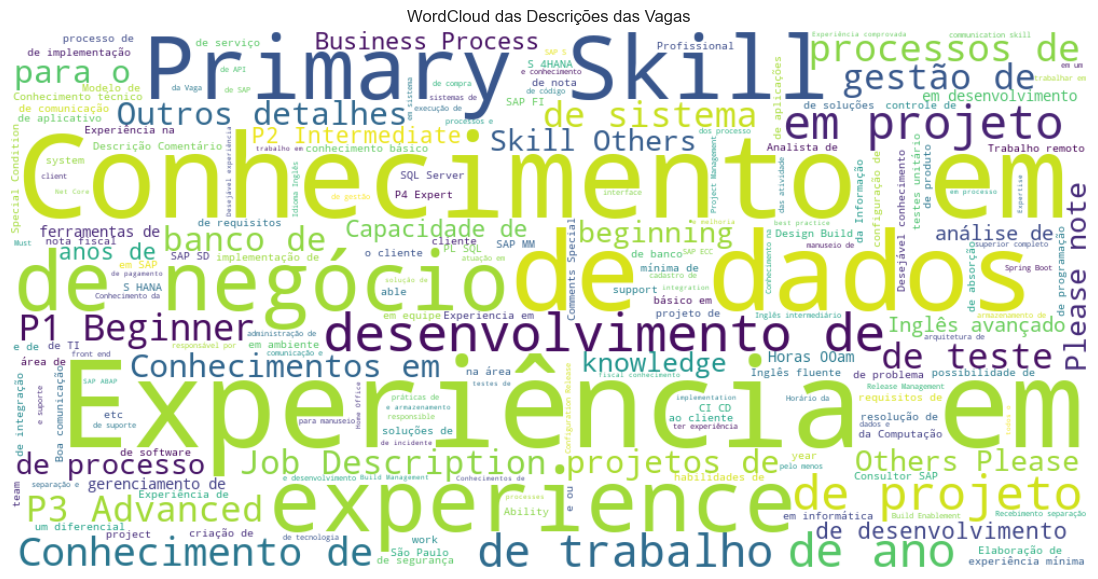

In [ ]:
# WordCloud das descrições de vagas
desc_vagas = []
for job in jobs.values():
    desc = job['perfil_vaga'].get('principais_atividades', '') + ' ' + \
           job['perfil_vaga'].get('competencia_tecnicas_e_comportamentais', '')
    desc_vagas.append(desc)

text = " ".join(desc_vagas)
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud das Descrições das Vagas")
plt.show()


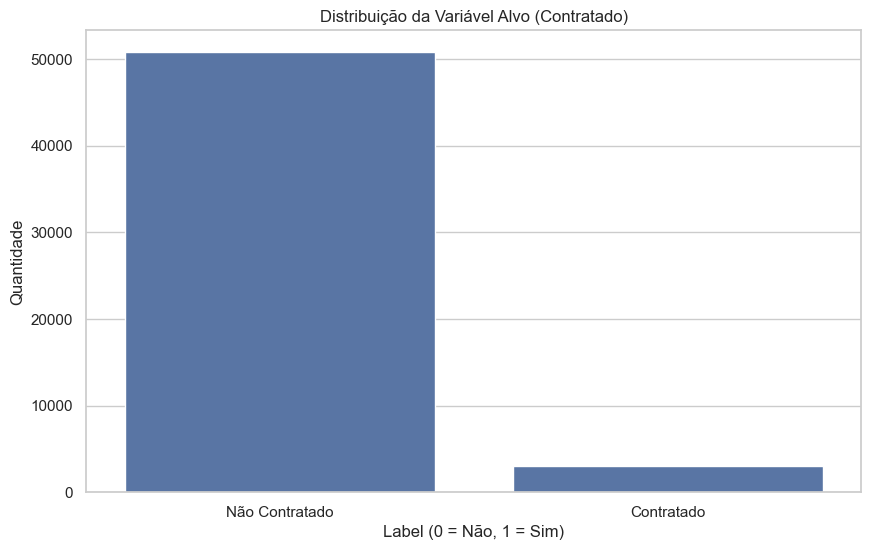

In [11]:
# Análise do "target" - Contratado vs Não contratado
labels = []
for job_id, data in prospects.items():
    for p in data['prospects']:
        label = 1 if 'Contratado' in p['situacao_candidado'] else 0
        labels.append(label)

sns.countplot(x=labels)
plt.title('Distribuição da Variável Alvo (Contratado)')
plt.xlabel('Label (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade')
plt.xticks([0, 1], ['Não Contratado', 'Contratado'])
plt.show()

In [12]:
# === ================================================ ===
# === Criação de features estruturadas para correlação ===
# === ================================================ ===

print("Gerando features estruturadas para análise de correlação...")

match_rows = []
for job_id, data in prospects.items():
    for p in data['prospects']:
        label = 1 if 'Contratado' in p['situacao_candidado'] else 0
        app = applicants.get(p['codigo'])
        job = jobs.get(job_id)

        if not app or not job:
            continue

        match_rows.append({
            'nivel_academico': app['formacao_e_idiomas'].get('nivel_academico', 'Desconhecido'),
            'nivel_ingles': app['formacao_e_idiomas'].get('nivel_ingles', 'Desconhecido'),
            'nivel_espanhol': app['formacao_e_idiomas'].get('nivel_espanhol', 'Desconhecido'),
            'area_atuacao': app['informacoes_profissionais'].get('area_atuacao', 'Desconhecido'),
            'label': label
        })

df_corr = pd.DataFrame(match_rows)
print(f"Total de registros estruturados: {len(df_corr)}")



Gerando features estruturadas para análise de correlação...
Total de registros estruturados: 45071


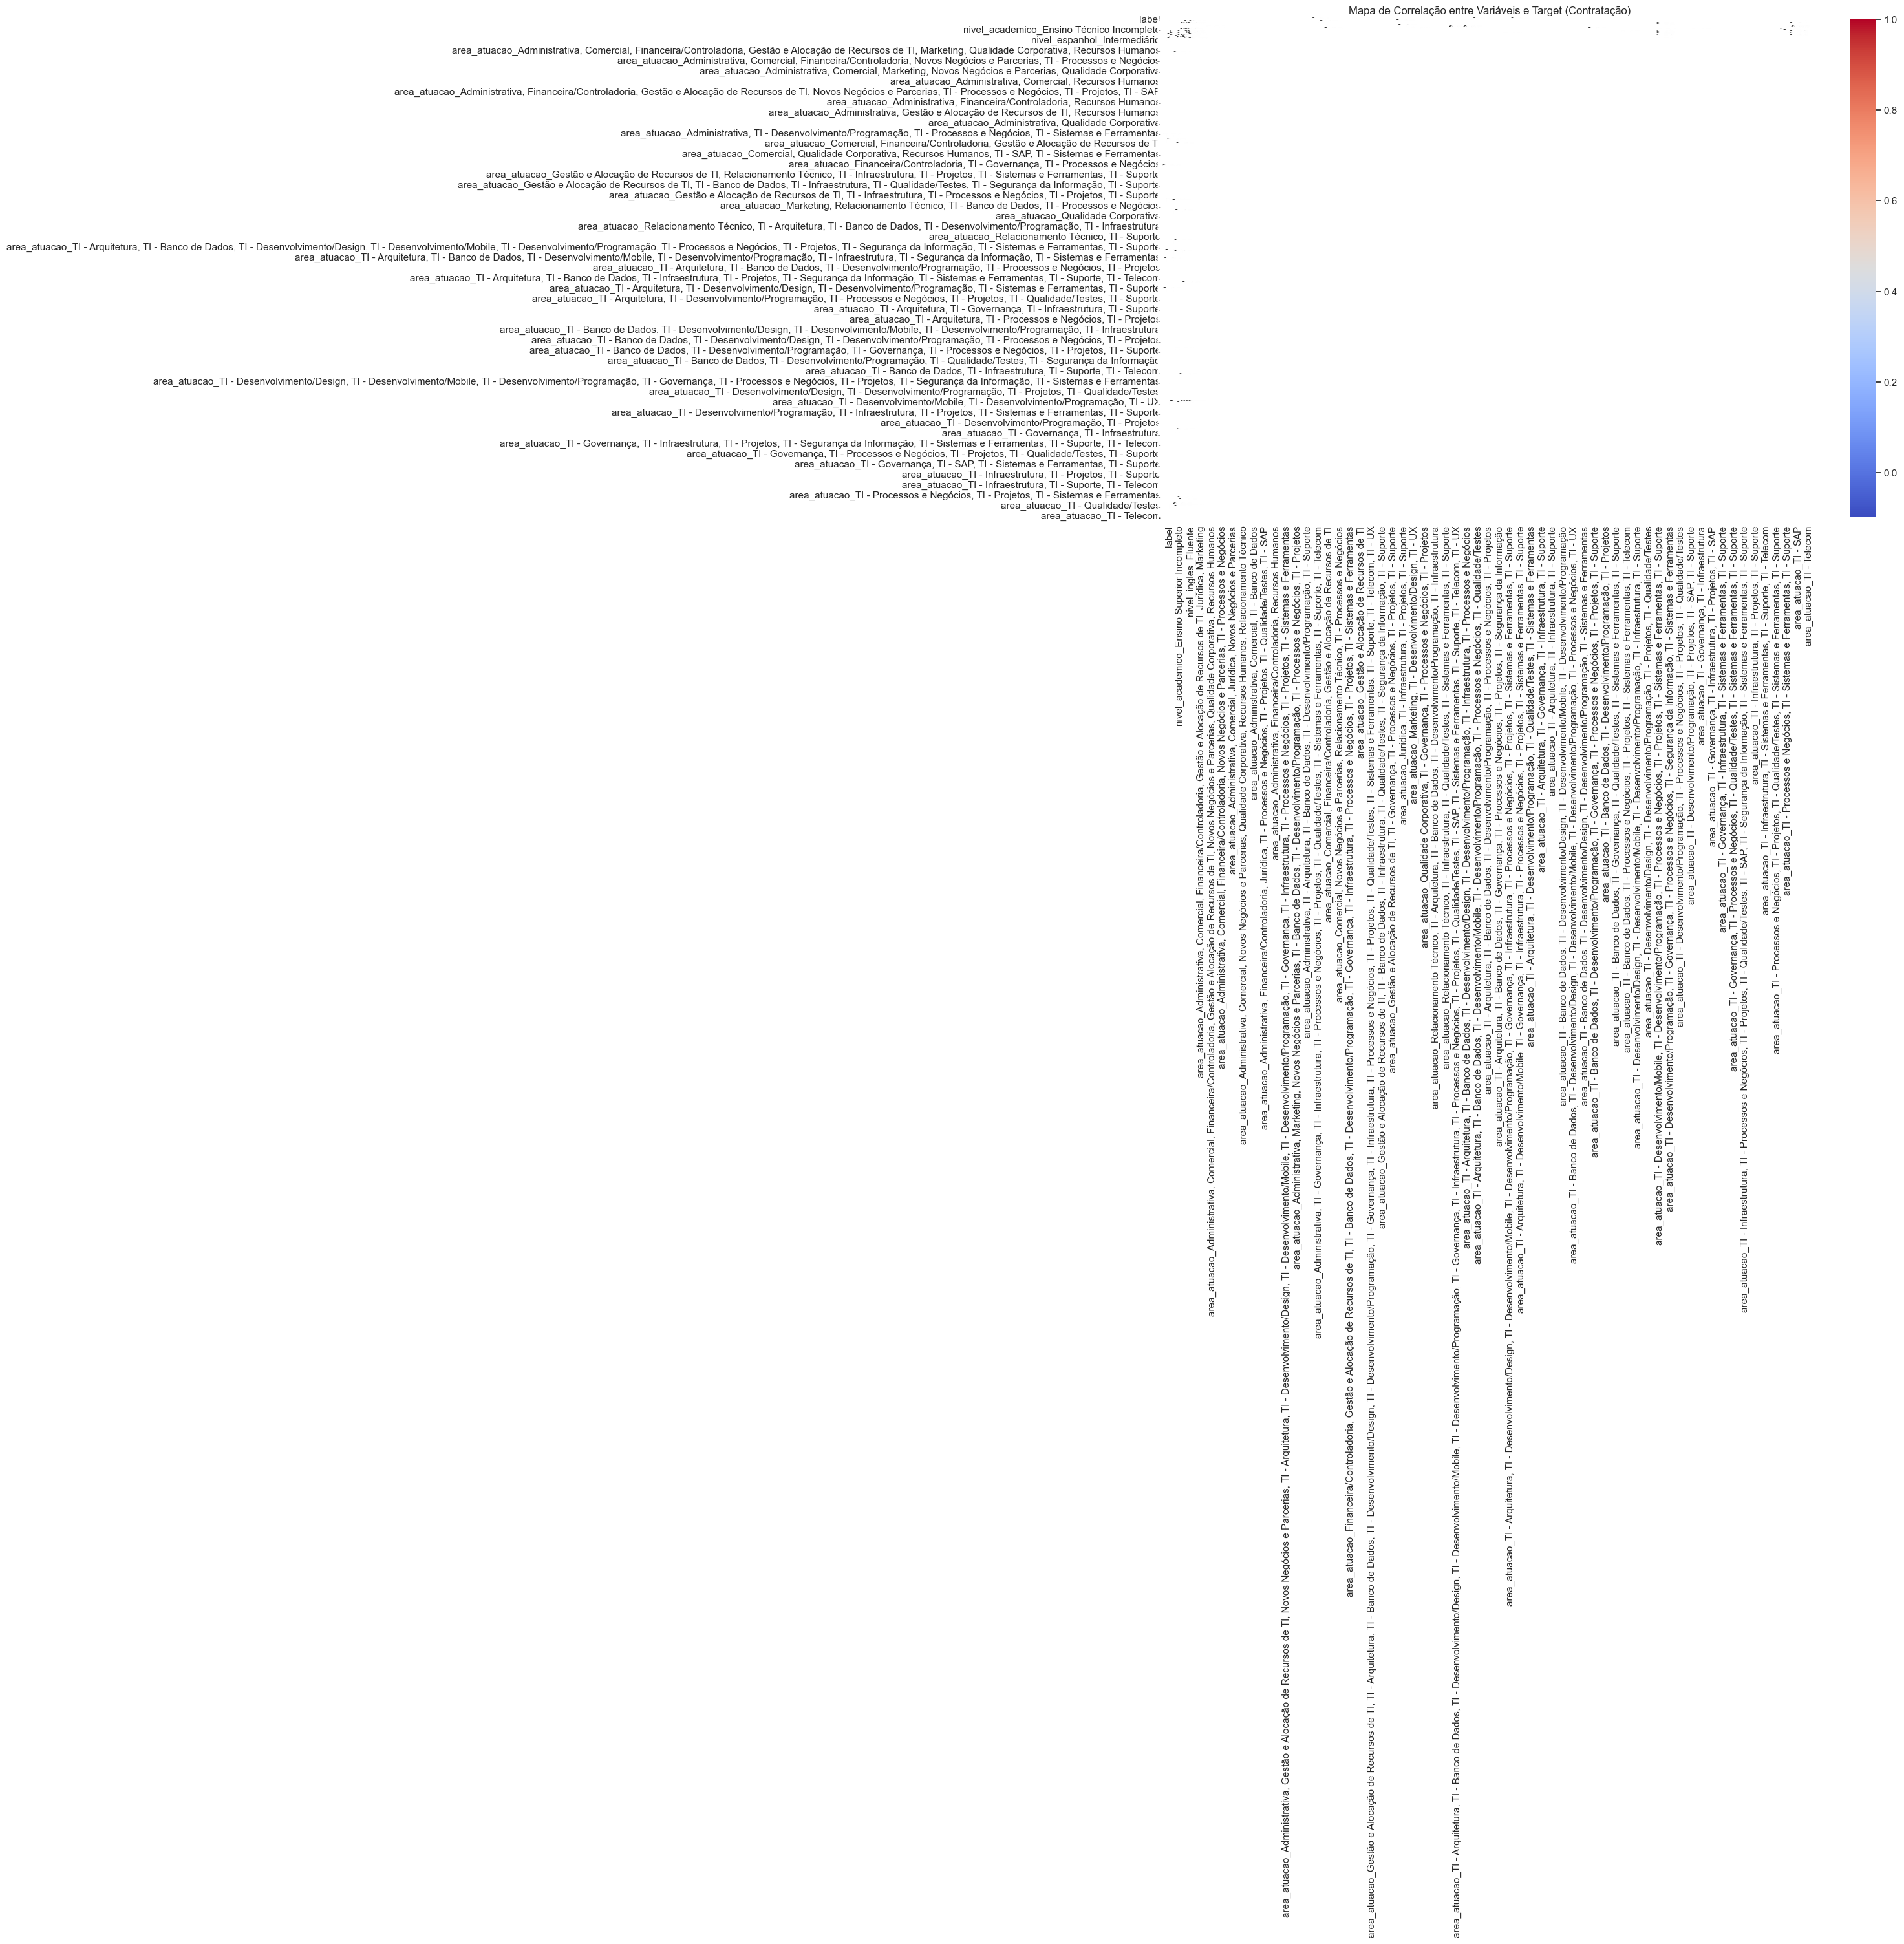

In [14]:
# === ==================================== ===
# === Transformação categórica -> numérica ===
# === ==================================== ===

df_encoded = pd.get_dummies(df_corr, drop_first=True)

# === ===================== ===
# === Análise de correlação ===
# === ===================== ===
plt.figure(figsize=(16, 10))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de Correlação entre Variáveis e Target (Contratação)")
plt.show()



Top 10 correlações com a variável 'label':


nivel_ingles_Intermediário                                                                                       -0.030068
nivel_academico_Pós Graduação Completo                                                                           -0.028506
area_atuacao_TI - Desenvolvimento/Programação, TI - Projetos, TI - Qualidade/Testes                               0.027930
nivel_ingles_Avançado                                                                                            -0.025867
nivel_academico_Ensino Superior Completo                                                                         -0.024704
nivel_espanhol_Intermediário                                                                                     -0.023881
nivel_espanhol_Básico                                                                                            -0.022580
area_atuacao_TI - Desenvolvimento/Design, TI - Projetos                                                           0.019749
area_atuacao_TI 

C:\Users\tatia\AppData\Local\Temp\ipykernel_21980\3075265826.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


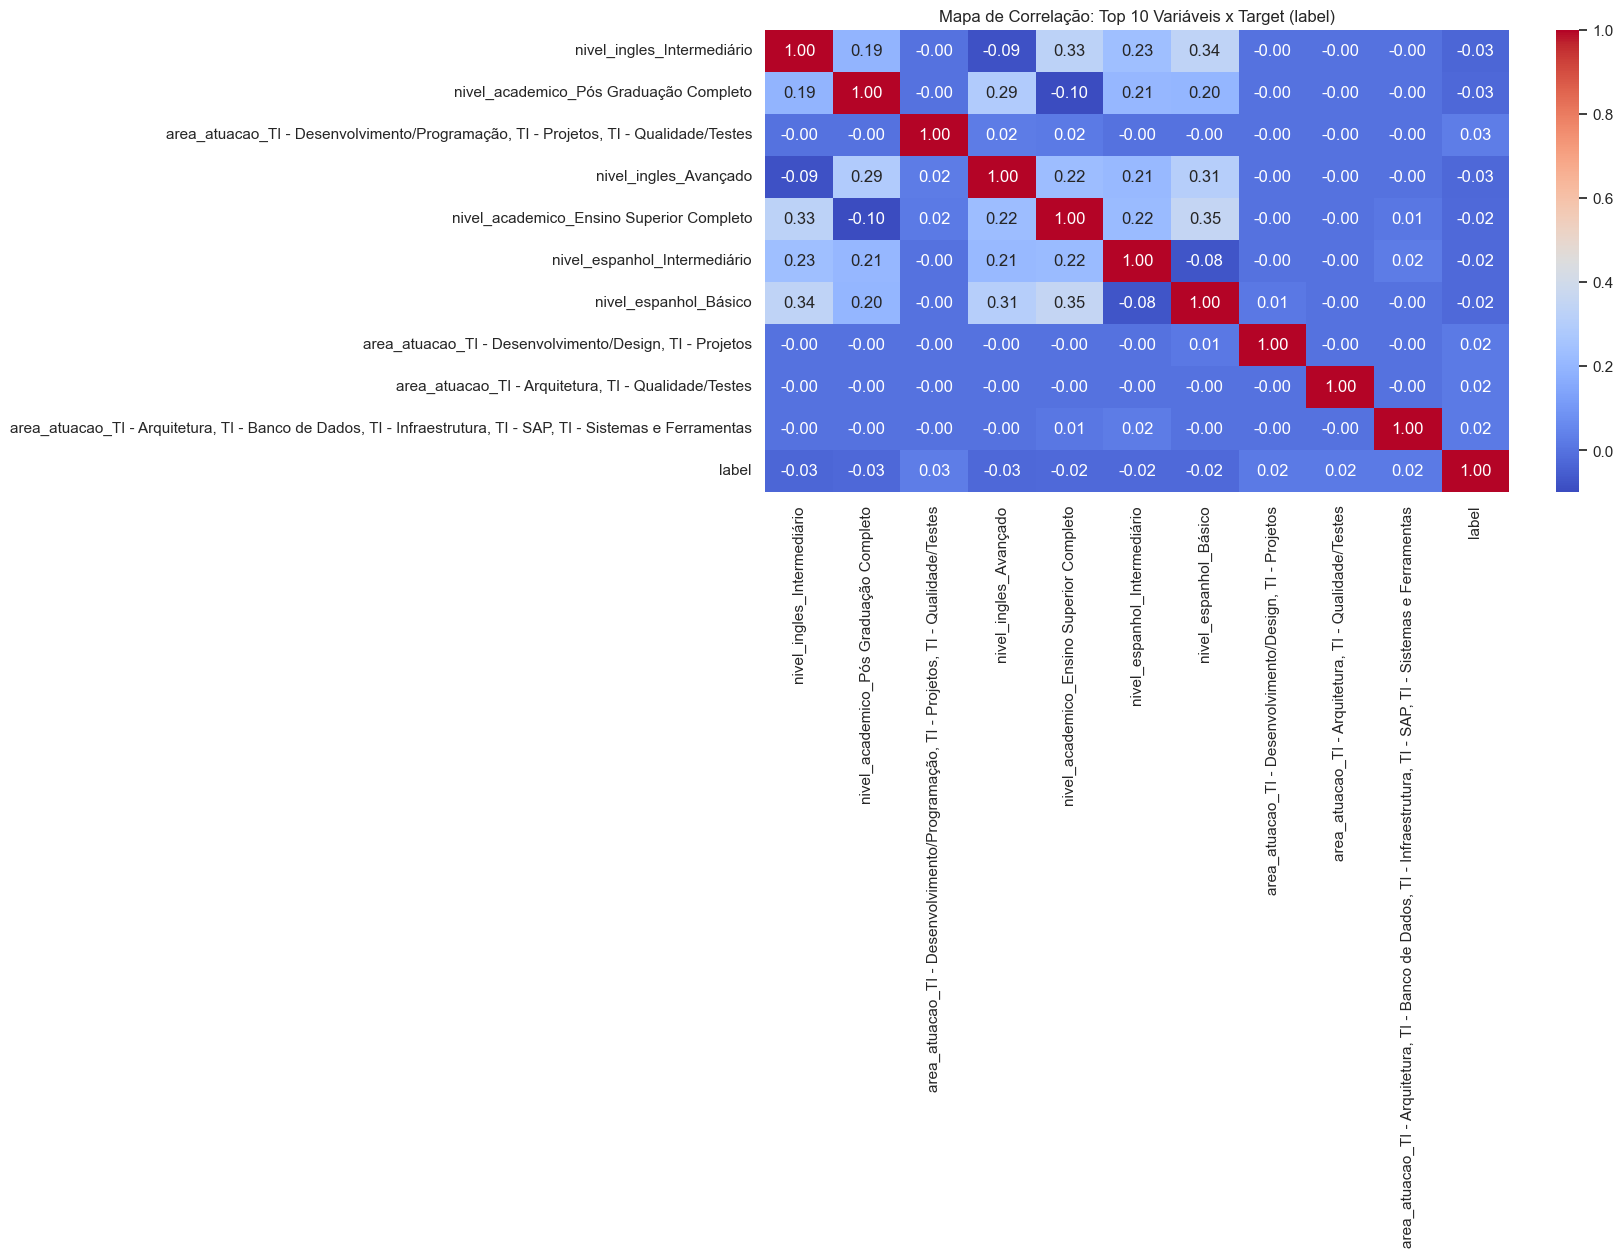

In [16]:
# === ==================================== ===
# === Transformação categórica -> numérica ===
# === ==================================== ===

df_encoded = pd.get_dummies(df_corr, drop_first=True)

# === ==================================== ===
# === Seleção das top 10 correlações       ===
# === ==================================== ===

# Calcula a correlação com a variável alvo
cor_target = df_encoded.corr()['label'].drop('label')

# Seleciona as top 10 variáveis com maior correlação (positiva ou negativa)
top_10_features = cor_target.abs().sort_values(ascending=False).head(10).index.tolist()

# Mostra os valores reais de correlação (com sinal)
top_10_correlations = cor_target[top_10_features]
print("Top 10 correlações com a variável 'label':")
display(top_10_correlations)

# === ===================== ===
# === Heatmap Top 10        ===
# === ===================== ===

plt.figure(figsize=(12, 6))
sns.heatmap(df_encoded[top_10_features + ['label']].corr(), 
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de Correlação: Top 10 Variáveis x Target (label)")
plt.tight_layout()
plt.show()

C:\Users\tatia\AppData\Local\Temp\ipykernel_21980\4048147930.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_sorted.values, y=top_10_sorted.index, palette="coolwarm", orient='h')


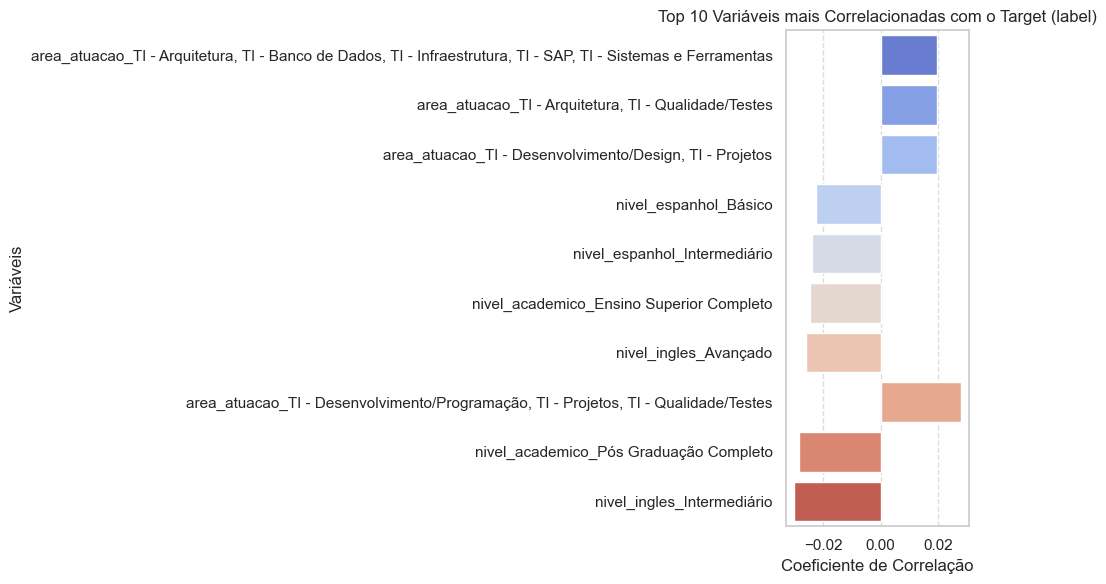

In [17]:
# === ================================= ===
# === Gráfico de barras das correlações ===
# === ================================= ===

# Ordena por valor absoluto da correlação
top_10_sorted = top_10_correlations.sort_values(key=lambda x: abs(x), ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_sorted.values, y=top_10_sorted.index, palette="coolwarm", orient='h')
plt.title("Top 10 Variáveis mais Correlacionadas com o Target (label)")
plt.xlabel("Coeficiente de Correlação")
plt.ylabel("Variáveis")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [18]:
# === ================================ ===
# === Correlação com a variável target ===
# === ================================ ===
cor_target = df_encoded.corr()['label'].sort_values(ascending=False)
print("Correlação das variáveis com o target (label):")
display(cor_target)


Correlação das variáveis com o target (label):


label                                                                                                             1.000000
area_atuacao_TI - Desenvolvimento/Programação, TI - Projetos, TI - Qualidade/Testes                               0.027930
area_atuacao_TI - Desenvolvimento/Design, TI - Projetos                                                           0.019749
area_atuacao_TI - Arquitetura, TI - Qualidade/Testes                                                              0.019749
area_atuacao_TI - Arquitetura, TI - Banco de Dados, TI - Infraestrutura, TI - SAP, TI - Sistemas e Ferramentas    0.019749
                                                                                                                    ...   
nivel_espanhol_Intermediário                                                                                     -0.023881
nivel_academico_Ensino Superior Completo                                                                         -0.024704
nivel_ingles_Ava